In [1]:
import random
import timeit
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
class RSA:
    """
    RSA implementation for encryption, signature and station-to-station key exchange.
    """

    def __init__(self, private_key: int = None, public_key: int = None, n: int = None, fast_exp: callable = None) -> None:
        self.private_key = private_key
        self.public_key = public_key
        self.n = n
        self.challenge = "Bravo ! Je suis épousplouffé par ta maîtrise du timing attack sur RSA !"
        self.fast_exp = fast_exp if fast_exp is not None else self._default_fast_exp
    
    def copy(self):
        return RSA(self.private_key, self.public_key, self.n, self.fast_exp)

    def _default_fast_exp(self, y: int, x: int, n: int) -> int:
        """Apply fast exponentiation for y^x modulo n"""
        s = 1
        y %= n

        while x > 0:
            if (x % 2) == 1:
                s = (s * y) % n
            y = (y * y) % n
            x = x >> 1

        return s

    def setKeys(self, private_key: int, public_key: int, n: int) -> None:
        self.private_key = private_key
        self.public_key = public_key
        self.n = n

    def getKeys(self) -> list:
        return [self.public_key, self.n], [self.private_key, self.n]
    
    def exportPublicKey(self) -> list:
        return [self.public_key, self.n]

    def createKeyPair(self, size: int) -> list:
        p = self.primary_nb_generator(2**(size//2 - 1), 2**(size//2))
        q = self.primary_nb_generator(2**(size//2 - 1), 2**(size//2))
        n, e, d = self.key_generator(p, q, size=size)
        self.setKeys(d, e, n)
        return [n, e, d]

    def encrypt(self, message: int) -> int:
        return self.fast_exp(message, self.public_key, self.n)

    def decrypt(self, cipher: int, private_key: int = None) -> int:
        if private_key is not None:
            return self.fast_exp(cipher, private_key, self.n)
        return self.fast_exp(cipher, self.private_key, self.n)
    
    def createChallenge(self) -> int:
        challenge_int = int.from_bytes(self.challenge.encode(), 'big')
        self.challenge = self.encrypt(challenge_int)
        return self.challenge
    
    def decryptChallenge(self, tested_key: int) -> str:
        decrypted_challenge_int = self.decrypt(self.challenge, private_key=tested_key)
        decrypted_challenge_bytes = decrypted_challenge_int.to_bytes((decrypted_challenge_int.bit_length() + 7) // 8, 'big')
        return decrypted_challenge_bytes.decode()

    def fermat_test(self, n: int) -> bool:
        """
        Check if a number is primary by running Fermat test.
        """
        for _ in range(20):
            alpha = random.randint(2, n - 1)
            if self.fast_exp(alpha, n - 1, n) != 1:
                return False
        return True

    def primary_nb_generator(self, a: int, b: int, safe_prime: bool = False) -> int:
        """
        Generate primary number in range a, b

        Parameters
        ----------
        a : int
            lower bound
        b : int
            upper bound
        safe_prime : bool
            Generate primary number p with (p - 1) / 2 also primary

        Returns
        -------
        int
            Primary number generated

        """
        while True:
            p = random.randint(a, b)
            if self.fermat_test(p):
                if safe_prime:
                    if self.fermat_test((p - 1) / 2):
                        return p
                else:
                    return p

    def Euclide(self, a: int, b: int) -> list:
        """
        Euclide's extended algorithm, used to find decryption exponent d for RSA
        Return a list [pgcd(a, b), inverse of a mod b, inverse of b mod a]

        """
        if b > a:
            a, b = b, a  # swap

        r_0, r_1 = a, b
        s_0, s_1 = 1, 0
        t_0, t_1 = 0, 1

        while r_1 != 0:
            q = r_0 // r_1
            r_0, r_1 = r_1, r_0 - q * r_1
            s_0, s_1 = s_1, s_0 - q * s_1
            t_0, t_1 = t_1, t_0 - q * t_1

        return [r_0, s_0 % b, t_0 % a]

    def key_generator(self, p: int = 0, q: int = 0, e: int = 0, size: int = 512) -> list:
        """
        Generate public and private key for RSA
        """
        if p == 0:
            p = self.primary_nb_generator(2**(size//2 - 1), 2**(size//2))
        if q == 0:
            q = self.primary_nb_generator(2**(size//2 - 1), 2**(size//2))

        assert self.fermat_test(p), "p is not primary"
        assert self.fermat_test(q), "q is not primary"
        n = p * q
        phi_n = (p - 1) * (q - 1)

        if e != 0:
            pgcd, _, d = self.Euclide(phi_n, e)
            assert pgcd == 1, "pgcd(phi_n, e) is not equal to 1, so no private key found !"

        else:
            # Find a primary number e with phi_n
            while True:
                e = random.randint(2**(size - 1), 2**(size))
                pgcd, _, d = self.Euclide(phi_n, e)

                # If primary number with phi_n, claim public key
                if pgcd == 1:
                    break
        return n, e, d

In [3]:
#----------------------------------------------------------------------------
# Examples values
#----------------------------------------------------------------------------

# for RSA encryption :

p_A = 13109499994810966779468866046493465498469807493634236479294124421385342920350717814807375283698575766763256101470694189234369358996750113963585617491399169
q_A = 9497561827984502554523100157901534504433126034087863778629488755692649311435921364240405549590851856701860175924335776598684751639633322074428628372725777
n_A = p_A * q_A
e_A = 4574830074548708213
m_1 = 123456789132456789

# Expected results :
# 1) Check if p and q are indeed prime, then compute d_A and the ciphertext.
# 2) Expected values for d_A and the ciphertext (d_A is also used for station-to-station later)
d_A = 1685394382767324790326942621450485552187209875614438478305225564629345944620726038114923060947436330701451901921041511234432041036987266468290187679773130363479895993621867708066144608084390089775045890165825736468637468786667820591136139480545376198614216373031208691260339805721685482401743494212035728605
# cipher = 32468932964181322647810913060097066975304467072050643211304428656476623133068329653886195740426516038144100129255895281039142864272296799126753030014464755203797098445143314298922512718785433009136404533290100525054356166805463645892708927694801117827432767298393815743170470207262077229267156532545837844746
# 3) And show the decryption indeed finds the correct message m_1.

print("\n=============== RSA ENCRYPTION ===============\n")

RSA_instance = RSA()
n, e, d = RSA_instance.key_generator(p_A, q_A, e_A)
RSA_instance.setKeys(d, e, n)
assert d == d_A, "Private key generated is different from the expected key !"

print(f"Message:                {m_1}\n")

cipher = RSA_instance.encrypt(m_1)
assert cipher == 32468932964181322647810913060097066975304467072050643211304428656476623133068329653886195740426516038144100129255895281039142864272296799126753030014464755203797098445143314298922512718785433009136404533290100525054356166805463645892708927694801117827432767298393815743170470207262077229267156532545837844746, "Encrypted message is not correct !"
print(f"Ciphertext:             {cipher}\n")

recovered_message = RSA_instance.decrypt(cipher)
assert recovered_message == m_1, "Recovered message is different from original message !"
print(f"Decrypted ciphertext:   {recovered_message}")


=============== RSA ENCRYPTION ===============

Message:                123456789132456789

Ciphertext:             32468932964181322647810913060097066975304467072050643211304428656476623133068329653886195740426516038144100129255895281039142864272296799126753030014464755203797098445143314298922512718785433009136404533290100525054356166805463645892708927694801117827432767298393815743170470207262077229267156532545837844746

Decrypted ciphertext:   123456789132456789


In [4]:
def collect_samples(
    RSA_instance: RSA,
    samples: np.ndarray = None,
    num_samples: int = 1000,
    num_repetitions: int = 10000,
    private_key: int = None,
    progress_bar: bool = True,
    warmup_reps: int = 200,
    use_median: bool = False
) -> np.ndarray:
    """Collect timing samples for RSA decryption.

    Each sample is a (ciphertext, min_time_ns) pair. The minimum over
    num_repetitions is used because OS jitter can only ADD latency —
    the minimum is therefore the best estimate of the true computation
    time, as established in the timing attack literature (Kocher 1996,
    Brumley & Boneh 2003).

    Parameters
    ----------
    RSA_instance : RSA
        An instance of the RSA class.
    samples : np.ndarray, optional
        Optional pre-generated samples to use instead of generating new ones.
         Each tuple should be (ciphertext, time_ns). If provided, num_samples is ignored.
    num_samples : int
        The number of (ciphertext, time) pairs to collect.
    num_repetitions : int
        The number of repetitions per sample. More = better chance of
        one clean, uninterrupted measurement.
    private_key : int, optional
        The private key to use. Defaults to RSA_instance.private_key.
    progress_bar : bool, default=True
        Whether to display a tqdm progress bar.
    warmup_reps : int, default=200
        Warm-up decryptions to stabilize CPU caches and branch predictor.
    use_median : bool, default=False
        Whether to use the median instead of the minimum as the timing estimator.

    Returns
    -------
    np.ndarray
        Array of shape (num_samples, 2): columns are [ciphertext, min_time_ns].
    """
    key = private_key if private_key is not None else RSA_instance.private_key
    n = RSA_instance.n
    decrypt_fn = RSA_instance.decrypt

    # --- Warm-up ---
    # Stabilise CPU caches and branch predictor before any measurement.
    # timeit handles GC disabling automatically.
    warmup_timer = timeit.Timer(
        stmt=lambda: decrypt_fn(random.randint(1, n - 1), private_key=key)
    )
    warmup_timer.timeit(number=warmup_reps)

    # --- Collection ---
    if samples is not None:
        result = samples.copy()
    else:
        result = np.empty((num_samples, 2), dtype=object)
        for i in range(num_samples):
            result[i, 0] = random.getrandbits(n.bit_length())

    for i in tqdm(range(len(result)), disable=not progress_bar, leave=False):
        cipher = result[i, 0]

        timer = timeit.Timer(
            stmt=lambda: decrypt_fn(cipher, private_key=key)
        )

        # repeat=num_repetitions, number=1 → one wall-clock measurement
        # per decryption call, in seconds. timeit disables GC automatically.
        raw_times_ns = np.array(
            timer.repeat(repeat=num_repetitions, number=1)
        ) * 1e9

        # The minimum is the best estimator of true decryption time.
        # OS interrupts can only ADD latency, never subtract it.
        if use_median:
            result[i, 1] = np.median(raw_times_ns)
        else:
            result[i, 1] = raw_times_ns.min()
    return result

In [5]:
def timing_attack(
    RSA_instance: RSA,
    num_samples: int = 1000,
    num_repetitions: int = 10000,
    num_iterations: int = 10,
    num_known_bits: int = 5,
    buffer_size: int = 5,
    warmup_reps: int = 200,
    progress_bar: bool = False,
) -> tuple[np.ndarray, list[float]]:
    """
    Perform a timing attack on RSA to recover the private key.

    Uses a beam search over key hypotheses: at each iteration, two
    candidate bits (0 and 1) are tested for each key in the buffer.
    The hypothesis that minimises variance of (server_time - local_time)
    is kept, exploiting the extra multiplication in square-and-multiply
    when a key bit is 1.

    Parameters
    ----------
    RSA_instance : RSA
        An instance of the RSA class.
    num_samples : int
        Number of ciphertext/time pairs to collect per measurement.
    num_repetitions : int
        Repetitions per ciphertext inside collect_samples. More reps
        = better min() estimate. Replaces the old disable_gc flag since
        timeit now handles GC automatically.
    num_iterations : int
        Number of key bits to recover (one per iteration).
    num_known_bits : int
        Number of LSBs of the private key assumed to be known.
    buffer_size : int
        Beam width: how many candidate keys to keep at each iteration.
    warmup_reps : int
        Warm-up decryptions before any measurement (default: 200).
    progress_bar : bool
        Whether to display a progress bar during sample collection.

    Returns
    -------
    tuple[np.ndarray, list[float]]
        candidate_keys : best `buffer_size` recovered key candidates.
        error_rate     : bit error rate (%) for each candidate.
    """
    # --- Collect server reference samples (true private key) ---
    server_samples = collect_samples(
        RSA_instance,
        num_samples=num_samples,
        num_repetitions=num_repetitions,
        warmup_reps=warmup_reps,
        use_median=False,
        progress_bar=progress_bar,
    )

    # --- Beam search initialisation ---
    initial_key = RSA_instance.private_key & ((1 << num_known_bits) - 1)
    candidate_keys      = np.full(buffer_size, initial_key)
    candidate_variances = np.full(buffer_size, np.inf)

    history_keys      = np.zeros((num_iterations, buffer_size))
    history_variances = np.zeros((num_iterations, buffer_size))

    # --- Bit-by-bit recovery ---
    for i in range(num_iterations):
        tested_keys      = []
        tested_variances = []

        for key in candidate_keys:
            # Hypothesis 0: next bit is 0
            key_h0 = key
            # Hypothesis 1: next bit is 1
            key_h1 = key | (1 << (num_known_bits + i))

            for hyp_key in (key_h0, key_h1):
                hyp_samples = collect_samples(
                    RSA_instance,
                    samples=server_samples,  # Reuse the same ciphertexts
                    num_repetitions=num_repetitions,
                    private_key=hyp_key,
                    warmup_reps=warmup_reps,
                    progress_bar=progress_bar,
                    use_median=False
                )
                # Variance of time difference: drops when key prefix matches
                # the real key (the extra multiplication aligns in time)
                variance = np.var(server_samples[:, 1] - hyp_samples[:, 1])
                tested_keys.append(hyp_key)
                tested_variances.append(variance)

        tested_keys      = np.array(tested_keys)
        tested_variances = np.array(tested_variances)

        # Keep the buffer_size best hypotheses (lowest variance)
        best_indices        = np.argsort(tested_variances)[:buffer_size]
        candidate_keys      = tested_keys[best_indices]
        candidate_variances = tested_variances[best_indices]

        history_keys[i]      = candidate_keys
        history_variances[i] = candidate_variances

        # --- Per-iteration debug print ---
        best_key       = candidate_keys[0]
        bit_guessed    = (best_key >> (num_known_bits + i)) & 1
        bit_real       = (RSA_instance.private_key >> (num_known_bits + i)) & 1
        h0_var         = tested_variances[tested_keys == key_h0][0]
        h1_var         = tested_variances[tested_keys == key_h1][0]
        correct        = "✓ CORRECT" if bit_guessed == bit_real else "✗ WRONG"
        print(
            f"Iteration {i+1:>{len(str(num_iterations))}}/{num_iterations}: "
            f"bit guessed = {bit_guessed}  "
            f"(var h0 = {h0_var:.4e}, var h1 = {h1_var:.4e})  {correct}"
        )

    # --- Final error rate across all candidates ---
    error_rates = []
    print(f"\n{'─' * 40}")
    for rank, (key, variance) in enumerate(zip(candidate_keys, candidate_variances)):
        guessed_bits = (key >> num_known_bits) % (1 << num_iterations)
        real_bits    = (RSA_instance.private_key >> num_known_bits) % (1 << num_iterations)
        n_errors     = (guessed_bits ^ real_bits).bit_count()
        rate         = n_errors / num_iterations * 100
        error_rates.append(rate)
        print(f"Candidate #{rank+1}")
        print(f"  Key:        {key}")
        print(f"  Variance:   {variance:.4e}")
        print(f"  Error rate: {rate:.2f}%  ({n_errors}/{num_iterations} bits wrong)")
        print(f"{'─' * 40}")

    return candidate_keys, error_rates

In [7]:
def get_samples_stats(
    RSA_instance: RSA,
    message: int,
    d_A: int,
    num_samples: int = 10000,
    warmup_reps: int = 200,
    progress_bar: bool = True,
) -> np.ndarray:
    """
    Collect individual decryption times for a single fixed ciphertext.
    Used to inspect the timing distribution (histogram, min, spread).

    Parameters
    ----------
    RSA_instance : RSA
    d_A : int
        Private key.
    num_samples : int
        Number of individual timing measurements to collect.
    warmup_reps : int
        Warm-up iterations to stabilise caches (default: 200).
    progress_bar : bool
        Show progress bar during measurement.

    Returns
    -------
    np.ndarray shape (num_samples,), times in nanoseconds.
    """
    decrypt_fn = RSA_instance.decrypt
    n = RSA_instance.n

    # Warm-up: timeit handles GC disabling automatically
    warmup_timer = timeit.Timer(
        stmt=lambda: decrypt_fn(message, private_key=d_A)
    )
    warmup_timer.timeit(number=warmup_reps)

    # One measurement per call (number=1), repeated num_samples times
    # This gives us the full distribution, not a single aggregate
    timer = timeit.Timer(
        stmt=lambda: decrypt_fn(message, private_key=d_A)
    )

    raw = list(
        tqdm(
            (t * 1e9 for t in timer.repeat(repeat=num_samples, number=1)),
            total=num_samples,
            desc="Sampling",
            disable=not progress_bar,
            leave=False,
        )
    )

    return np.array(raw, dtype=np.float64)


In [8]:
def plot_distributions(samples_stats_h0: np.ndarray, samples_stats_h1: np.ndarray, title: str = "Distribution of decryption times for two hypotheses with branch prediction"):
    plt.figure(figsize=(12, 6))
    plt.suptitle(title)
    plt.subplot(1, 2, 1)
    plt.hist(samples_stats_h0, bins=200)
    plt.axvline(np.min(samples_stats_h0), color='red', linestyle='dashed', linewidth=1, label=f'Min: {np.min(samples_stats_h0):.4f} ms')
    plt.title("Hypothesis h0: the last bit is 0")
    plt.xlabel("Decryption Time")
    plt.ylabel("Frequency")
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.hist(samples_stats_h1, bins=200)
    plt.axvline(np.min(samples_stats_h1), color='red', linestyle='dashed', linewidth=1, label=f'Min: {np.min(samples_stats_h1):.4f} ms')
    plt.title("Hypothesis h1: the last bit is 1")
    plt.xlabel("Decryption Time")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [9]:
def plot_distributions(samples_stats_h0: np.ndarray, samples_stats_h1: np.ndarray, title: str = "Distribution of decryption times for two hypotheses with branch prediction"):
    plt.figure(figsize=(12, 6))
    plt.suptitle(title)
    plt.subplot(1, 2, 1)
    plt.hist(samples_stats_h0, bins=200)
    plt.axvline(np.median(samples_stats_h0), color='red', linestyle='dashed', linewidth=1, label=f'Median: {np.median(samples_stats_h0):.4f} ms')
    plt.title("Hypothesis h0: the last bit is 0")
    plt.xlabel("Decryption Time")
    plt.ylabel("Frequency")
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.hist(samples_stats_h1, bins=200)
    plt.axvline(np.median(samples_stats_h1), color='red', linestyle='dashed', linewidth=1, label=f'Median: {np.median(samples_stats_h1):.4f} ms')
    plt.title("Hypothesis h1: the last bit is 1")
    plt.xlabel("Decryption Time")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [10]:
small_key = d_A & ((1 << 16) - 1)
h0_small_key = small_key
h1_small_key = small_key | (1 << 16)

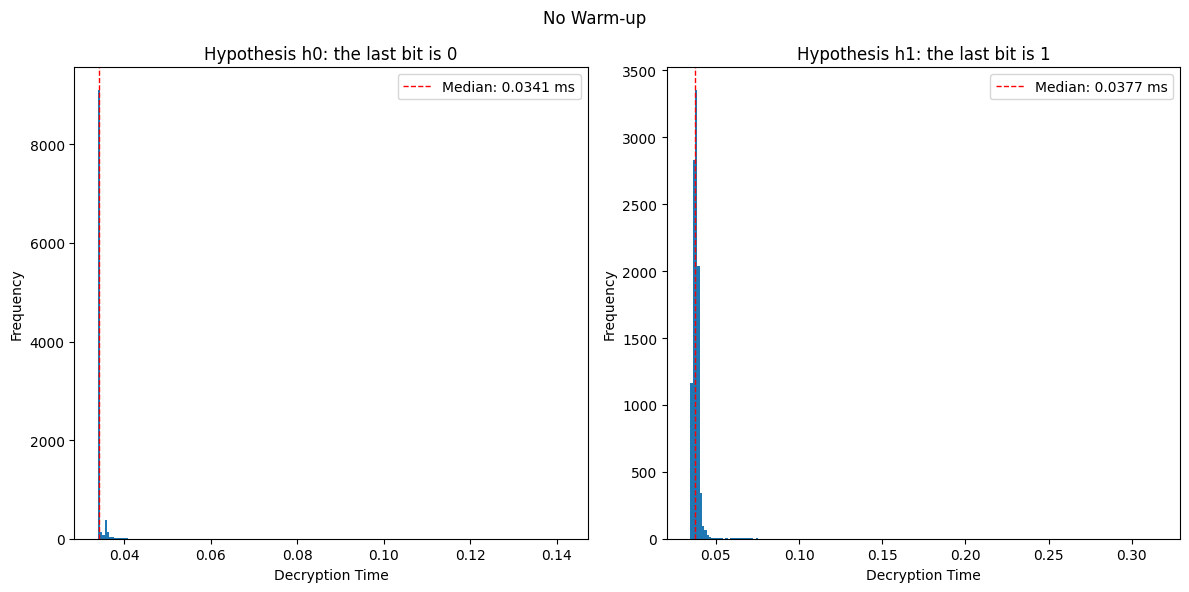

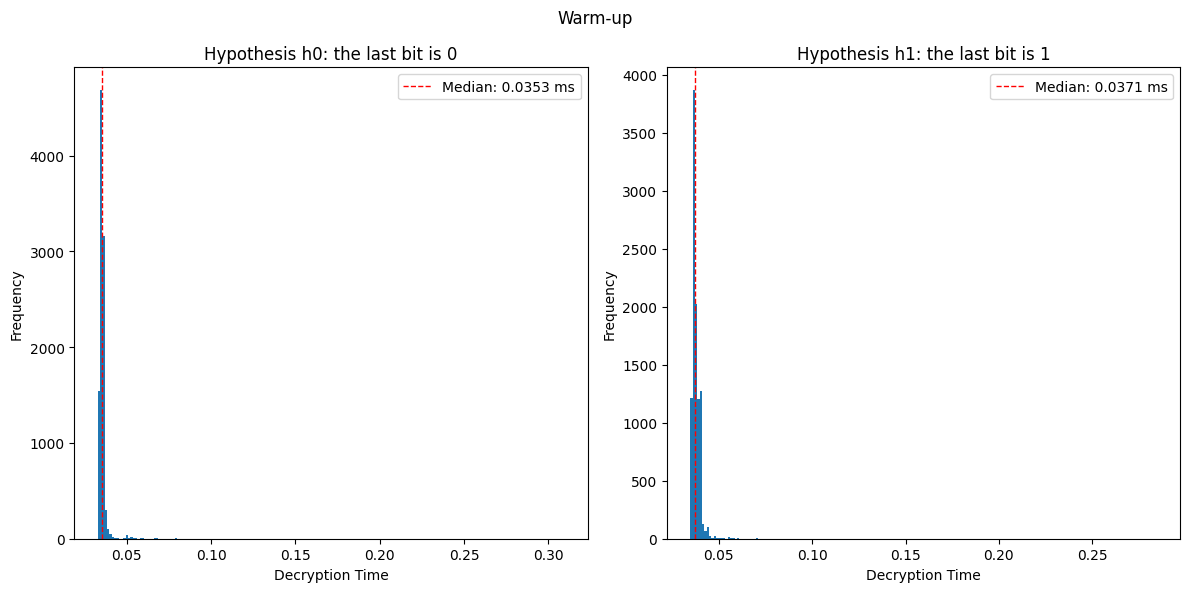

In [11]:
configs = {
    "No Warm-up" : dict( warmup_reps=0),
    "Warm-up"    : dict( warmup_reps=200),
}

results = {
    label: (
        get_samples_stats(RSA_instance, message=m_1, d_A=h0_small_key, **cfg) / 1e6,
        get_samples_stats(RSA_instance, message=m_1, d_A=h1_small_key, **cfg) / 1e6,
    )
    for label, cfg in configs.items()
}

for label, (h0, h1) in results.items():
    plot_distributions(h0, h1, title=label)

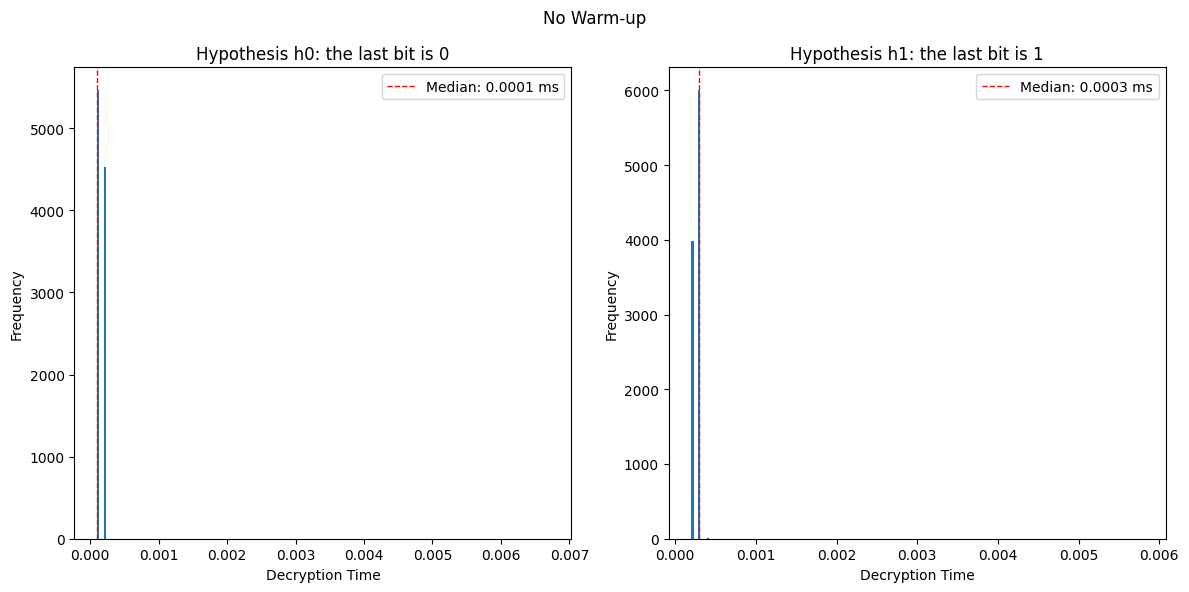

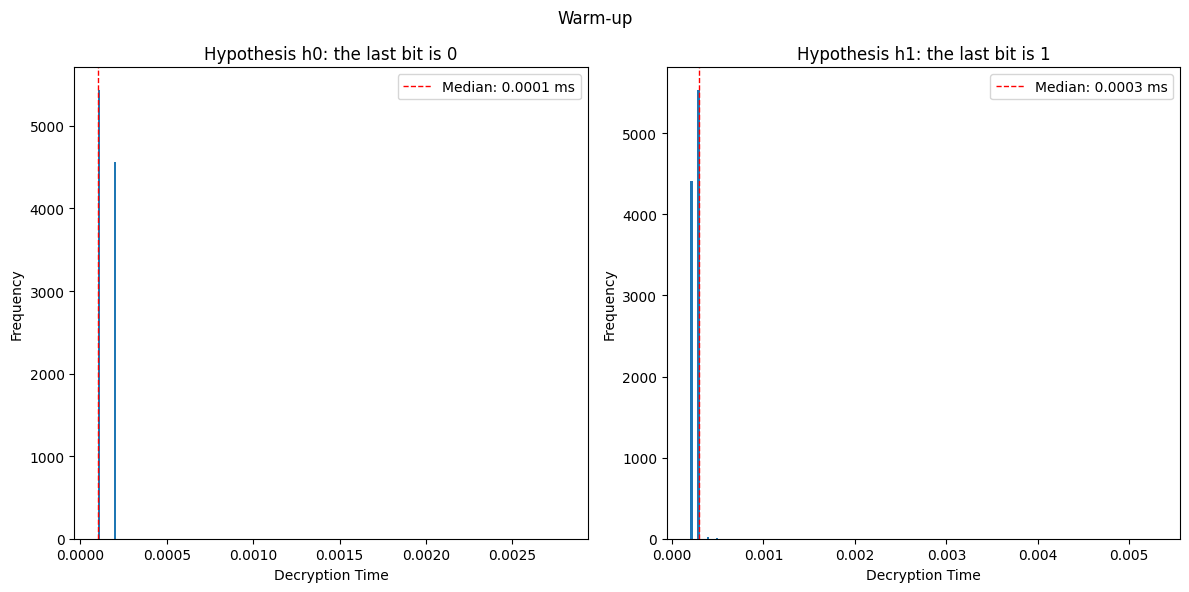

In [12]:
configs = {
    "No Warm-up" : dict(warmup_reps=0),
    "Warm-up"    : dict(warmup_reps=200),
}

results = {
    label: (
        get_samples_stats(RSA_instance, message=m_1, d_A=0, **cfg) / 1e6,
        get_samples_stats(RSA_instance, message=m_1, d_A=1, **cfg) / 1e6,
    )
    for label, cfg in configs.items()
}

for label, (h0, h1) in results.items():
    plot_distributions(h0, h1, title=label)

In [17]:
def plot_repetition_convergence(
    RSA_instance: RSA,
    message: int,
    d_h0: int,
    d_h1: int,
    sample_counts: list = [1, 10, 100, 500, 1000, 2000, 5000],
    warmup_reps: int = 200,
    n_runs: int = 10,
):
    h0_means_no_warmup = []
    h1_means_no_warmup = []
    h0_means_warmup = []
    h1_means_warmup = []

    for n in sample_counts:
        tmp_h0_no_warmup = []
        tmp_h1_no_warmup = []
        tmp_h0_warmup = []
        tmp_h1_warmup = []
        for _ in range(n_runs):
            tmp_h0_no_warmup.append(np.min(get_samples_stats(RSA_instance, message, d_A=d_h0, num_samples=n, warmup_reps=0)))
            tmp_h1_no_warmup.append(np.min(get_samples_stats(RSA_instance, message, d_A=d_h1, num_samples=n, warmup_reps=0)))
            tmp_h0_warmup.append(np.min(get_samples_stats(RSA_instance, message, d_A=d_h0, num_samples=n, warmup_reps=warmup_reps)))
            tmp_h1_warmup.append(np.min(get_samples_stats(RSA_instance, message, d_A=d_h1, num_samples=n, warmup_reps=warmup_reps)))
        h0_means_no_warmup.append(np.mean(tmp_h0_no_warmup))
        h1_means_no_warmup.append(np.mean(tmp_h1_no_warmup))
        h0_means_warmup.append(np.mean(tmp_h0_warmup))
        h1_means_warmup.append(np.mean(tmp_h1_warmup))
    
    plt.figure(figsize=(6, 6))
    plt.plot(sample_counts, h0_means_no_warmup, label='h0 no warm-up')
    plt.plot(sample_counts, h1_means_no_warmup, label='h1 no warm-up')
    plt.plot(sample_counts, h0_means_warmup, label='h0 warm-up')
    plt.plot(sample_counts, h1_means_warmup, label='h1 warm-up')
    plt.xscale('log')
    plt.xlabel('Number of samples')
    plt.ylabel('Minimum decryption time (ns)')
    plt.title('Convergence of minimum decryption time with number of samples')
    plt.legend()

    plt.tight_layout()
    plt.show()

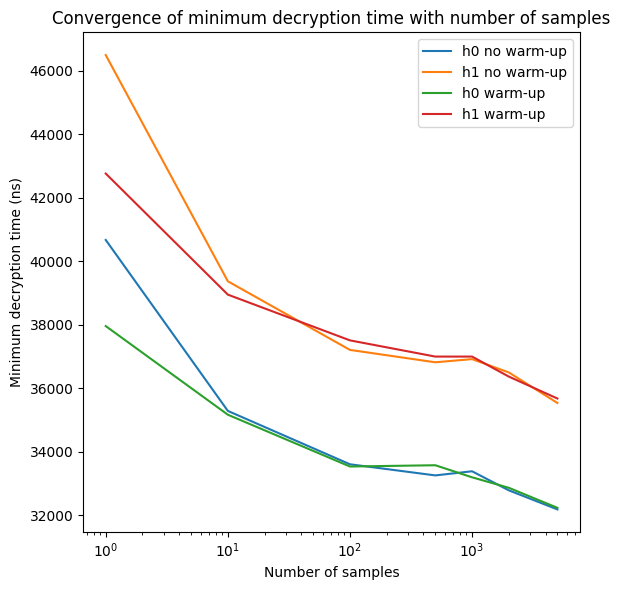

In [18]:
plot_repetition_convergence(RSA_instance, message=m_1, d_h0=h0_small_key, d_h1=h1_small_key)

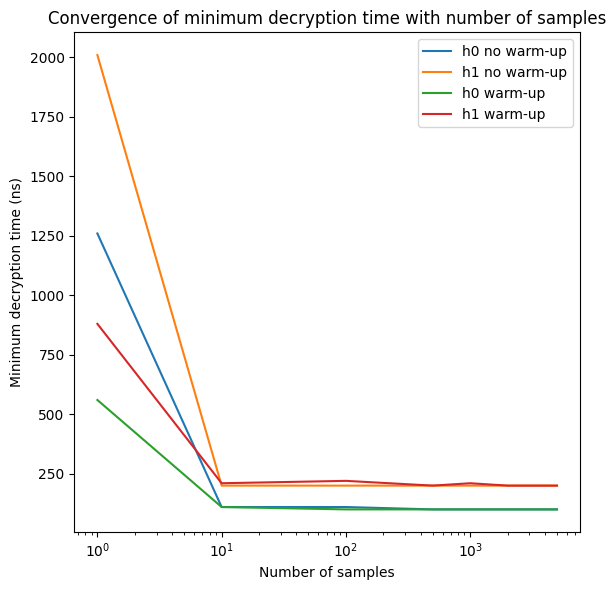

In [19]:
plot_repetition_convergence(RSA_instance, message=m_1, d_h0=0, d_h1=1)

In [22]:
def plot_warmup_convergence(
    RSA_instance: RSA,
    message: int,
    d_h0: int,
    d_h1: int,
    sample_counts: int = 200,
    warmup_reps: list =  [1, 10, 100, 200, 300, 400, 500, 1000],
    n_runs: int = 10,
):
    h0_means = []
    h1_means = []

    for n in warmup_reps:
        tmp_h0 = []
        tmp_h1 = []
        for _ in range(n_runs):
            tmp_h0.append(np.min(get_samples_stats(RSA_instance, message=message, d_A=d_h0, num_samples=sample_counts, warmup_reps=n)))
            tmp_h1.append(np.min(get_samples_stats(RSA_instance, message=message, d_A=d_h1, num_samples=sample_counts, warmup_reps=n)))

        h0_means.append(np.mean(tmp_h0))
        h1_means.append(np.mean(tmp_h1))

    plt.figure(figsize=(6, 6))
    plt.plot(warmup_reps, h0_means, label='h0')
    plt.plot(warmup_reps, h1_means, label='h1')
    plt.xlabel('Number of warm-up repetitions')
    plt.ylabel('Minimum decryption time (ns)')
    plt.title('Convergence of minimum decryption time with number of warm-up repetitions')
    plt.legend()

    plt.tight_layout()
    plt.show()

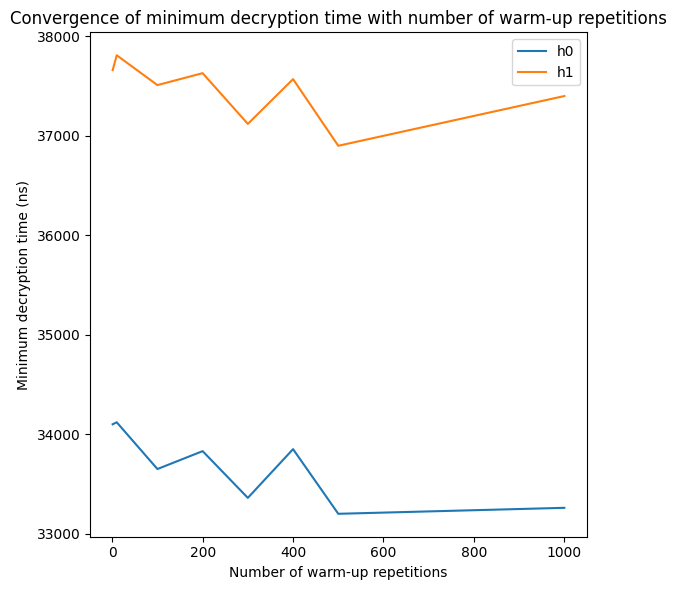

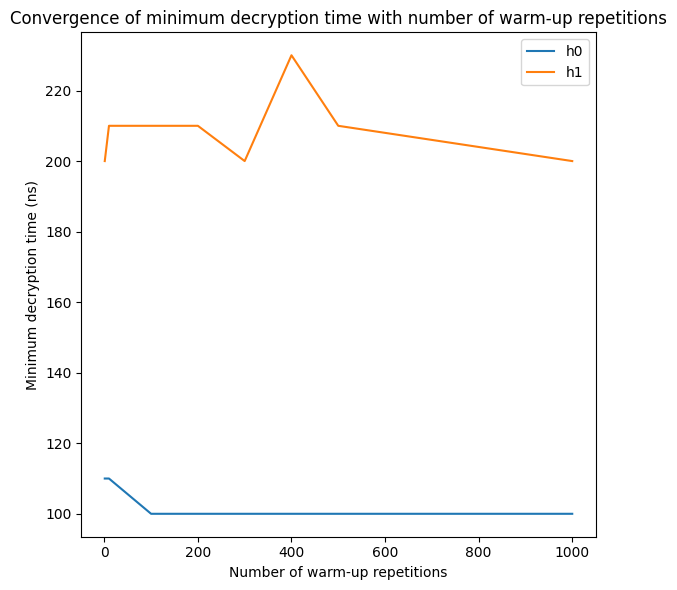

In [24]:
plot_warmup_convergence(RSA_instance, message=m_1, d_h0=h0_small_key, d_h1=h1_small_key)
plot_warmup_convergence(RSA_instance, message=m_1, d_h0=0, d_h1=1)

In [ ]:
# The execution of this cell takes around 13 hours with the current parameters !
# timing_attack(RSA_instance, num_samples=1000, num_repetitions=10000, num_iterations=5, num_known_bits=16, buffer_size=3, warmup_reps=0, progress_bar=True)

Iteration 1/5: bit guessed = 1  (var h0 = 1.5563e+08, var h1 = 1.5628e+08)  ✗ WRONG


Iteration 2/5: bit guessed = 1  (var h0 = 1.5586e+08, var h1 = 1.5514e+08)  ✓ CORRECT


Iteration 3/5: bit guessed = 1  (var h0 = 1.5520e+08, var h1 = 1.5653e+08)  ✓ CORRECT


Iteration 4/5: bit guessed = 0  (var h0 = 1.5497e+08, var h1 = 1.5614e+08)  ✓ CORRECT


Iteration 5/5: bit guessed = 1  (var h0 = 1.5522e+08, var h1 = 1.5507e+08)  ✓ CORRECT

────────────────────────────────────────
Candidate #1
  Key:        1234141
  Variance:   1.5475e+08
  Error rate: 20.00%  (1/5 bits wrong)
────────────────────────────────────────
Candidate #2
  Key:        1496285
  Variance:   1.5507e+08
  Error rate: 0.00%  (0/5 bits wrong)
────────────────────────────────────────
Candidate #3
  Key:        447709
  Variance:   1.5522e+08
  Error rate: 20.00%  (1/5 bits wrong)
────────────────────────────────────────


(array([1234141, 1496285,  447709]), [20.0, 0.0, 20.0])

In [38]:
def predict(ciphers: np.ndarray, key: int, n: int, bits: int) -> np.ndarray:
    """
    Hamming-weight leakage model for square-and-multiply.

    Mirrors the loop exactly:
        if (x % 2) == 1: s = (s * y) % n    ← cost += t_mul * HW(s)
        y = (y * y) % n                       ← cost += t_sq  * HW(y)
        x >>= 1

    Intermediate values depend on the ciphertext, giving per-sample
    variation required for a non-degenerate Pearson correlation.
    """
    costs = np.zeros(len(ciphers))
    for j, c in enumerate(ciphers):
        y, s, x = int(c) % n, 1, key
        for _ in range(bits):
            if x & 1:
                s = (s * y) % n
                costs[j] += s.bit_count()
            y = (y * y) % n
            x >>= 1
    return costs


def timing_attack_pearson(
    RSA_instance,
    server_samples: np.ndarray = None,
    num_samples:    int   = 100,
    num_repetitions:int   = 1000,
    num_iterations: int   = 10,
    num_known_bits: int   = 5,
    buffer_size:    int   = 5,
    progress_bar:   bool  = False,
) -> tuple[np.ndarray, list[float]]:
    """
    Perform a timing attack on RSA to recover the private key.

    Same beam-search structure as the variance-based attack, but the
    hypothesis score is now Pearson r(server_times, predicted_times)
    instead of Var(server_times - local_times).  No local decryptions
    are performed — the leakage model (_predict) replaces them.

    Parameters
    ----------
    RSA_instance    : RSA
    num_samples     : ciphertext/time pairs collected from the server
    num_repetitions : repetitions per ciphertext (min-time estimator)
    num_iterations  : number of private-key bits to recover
    num_known_bits  : number of LSBs assumed known
    buffer_size     : beam width (candidate keys kept per iteration)
    progress_bar    : display progress bar during sample collection

    Returns
    -------
    candidate_keys : np.ndarray  — best buffer_size recovered keys
    error_rates    : list[float] — bit error rate (%) per candidate
    """
    # --- Collect server reference samples (true private key) ---
    if server_samples is None:
        server_samples = collect_samples(
            RSA_instance,
            num_samples=num_samples,
            num_repetitions=num_repetitions,
            warmup_reps=0,
            progress_bar=progress_bar,
    )

    ciphers      = server_samples[:, 0].astype(object)
    server_times = server_samples[:, 1].astype(float)
    n            = RSA_instance.n

    # --- Beam search initialisation ---
    initial_key       = RSA_instance.private_key & ((1 << num_known_bits) - 1)
    candidate_keys    = np.full(buffer_size, initial_key, dtype=object)
    candidate_corrs   = np.full(buffer_size, -np.inf)

    history_keys  = np.zeros((num_iterations, buffer_size), dtype=object)
    history_corrs = np.zeros((num_iterations, buffer_size))

    # --- Bit-by-bit recovery ---
    for i in range(num_iterations):
        tested_keys  = []
        tested_corrs = []
        # NEW: map from each hyp_key → its parent and whether it's h1
        hyp_meta = {}  # hyp_key → (parent_key, is_h1)

        for key in np.unique(candidate_keys):
            key_h0 = int(key)
            key_h1 = int(key) | (1 << (num_known_bits + i))

            for hyp_key in (key_h0, key_h1):
                predicted = predict(ciphers, hyp_key, n, bits=num_known_bits + i + 1)
                if predicted.std() < 1e-12 or server_times.std() < 1e-12:
                    r = 0.0  # Avoid division by zero in correlation calculation
                else:
                    r = np.corrcoef(server_times, predicted)[0, 1]
                tested_keys.append(hyp_key)
                tested_corrs.append(r)
                hyp_meta[hyp_key] = (int(key), hyp_key == key_h1)  # NEW

        tested_keys  = np.array(tested_keys,  dtype=object)
        tested_corrs = np.array(tested_corrs, dtype=float)

        best_indices    = np.argsort(tested_corrs)[::-1][:buffer_size]
        candidate_keys  = tested_keys[best_indices]
        candidate_corrs = tested_corrs[best_indices]

        if len(candidate_keys) < buffer_size:
            pad = buffer_size - len(candidate_keys)
            candidate_keys  = np.concatenate([candidate_keys,  np.full(pad, candidate_keys[-1],  dtype=object)])
            candidate_corrs = np.concatenate([candidate_corrs, np.full(pad, candidate_corrs[-1], dtype=float)])

        history_keys[i]  = candidate_keys
        history_corrs[i] = candidate_corrs

        # --- FIXED debug print ---
        best_key    = int(candidate_keys[0])
        bit_guessed = (best_key >> (num_known_bits + i)) & 1
        bit_real    = (RSA_instance.private_key >> (num_known_bits + i)) & 1
        correct     = "✓ CORRECT" if bit_guessed == bit_real else "✗ WRONG"

        # Retrieve h0/h1 for the WINNING candidate's parent
        parent_key, _ = hyp_meta[best_key]
        h0_key = parent_key                              # bit forced to 0 (unchanged)
        h1_key = parent_key | (1 << (num_known_bits + i))  # bit forced to 1
        h0_mask = tested_keys == h0_key
        h1_mask = tested_keys == h1_key
        h0_corr = tested_corrs[h0_mask][0] if h0_mask.any() else float('nan')
        h1_corr = tested_corrs[h1_mask][0] if h1_mask.any() else float('nan')

        print(
            f"Iteration {i+1:>{len(str(num_iterations))}}/{num_iterations}: "
            f"bit guessed = {bit_guessed}  "
            f"(r h0 = {h0_corr:+.4f}, r h1 = {h1_corr:+.4f})  {correct}"
        )

    # --- Final error rate across all candidates ---
    error_rates = []
    print(f"\n{'─' * 40}")
    for rank, (key, corr) in enumerate(zip(candidate_keys, candidate_corrs)):
        guessed_bits = (int(key) >> num_known_bits) % (1 << num_iterations)
        real_bits    = (RSA_instance.private_key >> num_known_bits) % (1 << num_iterations)
        n_errors     = (guessed_bits ^ real_bits).bit_count()
        rate         = n_errors / num_iterations * 100
        error_rates.append(rate)
        print(f"Candidate #{rank + 1}")
        print(f"  Key:        {key}")
        print(f"  Pearson r:  {corr:+.4f}")
        print(f"  Error rate: {rate:.2f}%  ({n_errors}/{num_iterations} bits wrong)")
        print(f"{'─' * 40}")

    return candidate_keys, error_rates

In [39]:
import os

# Save the collected samples to a file
if os.path.exists("server_samples_median.npy"):
    print("File 'server_samples_median.npy' already exists !")
else:
    print("File 'server_samples_median.npy' does not exist. Creating it with new data.")
    server_samples_median = collect_samples(RSA_instance, num_samples=3000, num_repetitions=500, progress_bar=True, use_median=True)
    np.save("server_samples_median.npy", server_samples_median)

# Load the samples from the file
server_samples_median = np.load("server_samples_median.npy", allow_pickle=True)

File 'server_samples_median.npy' already exists !


In [47]:
timing_attack_pearson(RSA_instance, server_samples=server_samples_median, num_iterations=10, num_known_bits=16, buffer_size=3, progress_bar=True)

Iteration  1/10: bit guessed = 0  (r h0 = -0.0022, r h1 = -0.0104)  ✓ CORRECT
Iteration  2/10: bit guessed = 1  (r h0 = -0.0022, r h1 = -0.0018)  ✓ CORRECT
Iteration  3/10: bit guessed = 1  (r h0 = -0.0018, r h1 = +0.0014)  ✓ CORRECT
Iteration  4/10: bit guessed = 1  (r h0 = +0.0014, r h1 = +0.0022)  ✗ WRONG
Iteration  5/10: bit guessed = 1  (r h0 = +0.0022, r h1 = +0.0107)  ✓ CORRECT
Iteration  6/10: bit guessed = 0  (r h0 = +0.0107, r h1 = +0.0090)  ✓ CORRECT
Iteration  7/10: bit guessed = 0  (r h0 = +0.0107, r h1 = +0.0025)  ✗ WRONG
Iteration  8/10: bit guessed = 1  (r h0 = +0.0107, r h1 = +0.0136)  ✓ CORRECT
Iteration  9/10: bit guessed = 1  (r h0 = +0.0107, r h1 = +0.0145)  ✗ WRONG
Iteration 10/10: bit guessed = 1  (r h0 = +0.0118, r h1 = +0.0178)  ✓ CORRECT

────────────────────────────────────────
Candidate #1
  Key:        60740829
  Pearson r:  +0.0178
  Error rate: 30.00%  (3/10 bits wrong)
────────────────────────────────────────
Candidate #2
  Key:        52352221
  Pearson

(array([60740829, 52352221, 18797789], dtype=object), [30.0, 40.0, 50.0])

In [42]:
# Save server_samples_min to a file
# Check if the file already exists to avoid overwriting
import os

if os.path.exists("server_samples_min.npy"):
    print("File 'server_samples_min.npy' already exists !")
else:
    print("File 'server_samples_min.npy' does not exist. Creating it with new data.")
    server_samples_min = collect_samples(RSA_instance, num_samples=3000, num_repetitions=500, use_median=False, progress_bar=True)
    np.save("server_samples_min.npy", server_samples_min)

# Load server_samples_min from the file
server_samples_min = np.load("server_samples_min.npy", allow_pickle=True)

File 'server_samples_min.npy' already exists !


In [48]:
timing_attack_pearson(RSA_instance, server_samples=server_samples_min, num_iterations=10, num_known_bits=16, buffer_size=3, progress_bar=True)

Iteration  1/10: bit guessed = 1  (r h0 = -0.0191, r h1 = -0.0121)  ✗ WRONG
Iteration  2/10: bit guessed = 0  (r h0 = -0.0121, r h1 = -0.0123)  ✗ WRONG
Iteration  3/10: bit guessed = 1  (r h0 = -0.0121, r h1 = -0.0077)  ✓ CORRECT
Iteration  4/10: bit guessed = 1  (r h0 = -0.0121, r h1 = -0.0036)  ✗ WRONG
Iteration  5/10: bit guessed = 1  (r h0 = -0.0062, r h1 = +0.0006)  ✓ CORRECT
Iteration  6/10: bit guessed = 0  (r h0 = +0.0006, r h1 = -0.0009)  ✓ CORRECT
Iteration  7/10: bit guessed = 1  (r h0 = +0.0006, r h1 = +0.0025)  ✓ CORRECT
Iteration  8/10: bit guessed = 1  (r h0 = +0.0025, r h1 = +0.0029)  ✓ CORRECT
Iteration  9/10: bit guessed = 1  (r h0 = +0.0029, r h1 = +0.0041)  ✗ WRONG
Iteration 10/10: bit guessed = 1  (r h0 = +0.0029, r h1 = +0.0103)  ✓ CORRECT

────────────────────────────────────────
Candidate #1
  Key:        48157917
  Pearson r:  +0.0103
  Error rate: 10.00%  (1/10 bits wrong)
────────────────────────────────────────
Candidate #2
  Key:        64935133
  Pearson r

(array([48157917, 64935133, 31380701], dtype=object), [10.0, 20.0, 30.0])

100%|██████████| 20/20 [08:00<00:00, 24.03s/it] 


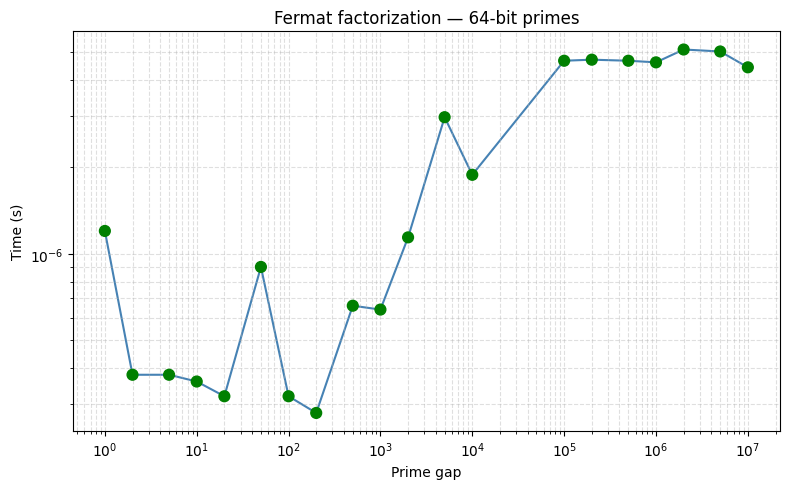

In [50]:
import gmpy2, random, time
import numpy as np
import matplotlib.pyplot as plt

def make_n(bits: int, gap: int) -> int:
    """
    Generate a product of two primes p and q, where q is the gap-th prime after p.
    """
    p = gmpy2.next_prime(random.getrandbits(bits))
    q = p
    for _ in range(gap): q = gmpy2.next_prime(q)
    return p * q

def fermat(n: int, max_iter: int = 2_000_000) -> tuple[int, float, bool]:
    a = gmpy2.isqrt(n) + 1
    t0 = time.perf_counter()
    for i in range(max_iter):
        b2 = a*a - n
        b  = gmpy2.isqrt(b2)
        if b*b == b2:
            return i+1, time.perf_counter() - t0, True
        a += 1
    return max_iter, time.perf_counter() - t0, False

# ── Config ─────────────────────────────────────────────────────────────────
BITS     = 64
MAX_ITER = 2_000_000
REPEATS  = 5
GAPS     = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1_000, 2_000, 5_000, 10_000, 100_000, 200_000, 500_000, 1_000_000, 2_000_000, 5_000_000, 10_000_000]

# ── Benchmark ──────────────────────────────────────────────────────────────
gaps, times, colors = [], [], []
for gap in tqdm(GAPS):
    runs     = [fermat(make_n(BITS, gap), MAX_ITER) for _ in range(REPEATS)]
    t        = np.mean([r[1] for r in runs])
    success  = np.mean([r[2] for r in runs])
    gaps.append(gap)
    times.append(t)
    colors.append("green" if success == 1 else "orange" if success > 0 else "red")

# ── Plot ───────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.plot(gaps, times, color="steelblue", zorder=1)
plt.scatter(gaps, times, c=colors, zorder=2, s=60)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Prime gap"); plt.ylabel("Time (s)")
plt.title(f"Fermat factorization — {BITS}-bit primes")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()